# TED 02 – Limpeza, Saneamento e Análise Exploratória

## Projeto IAnjos de Patas

Este notebook apresenta o processo de inspeção, limpeza, preparação e análise exploratória do conjunto de dados PetFinder utilizado no projeto IAnjos de Patas.

O objetivo desta etapa é identificar problemas de qualidade dos dados, justificar os tratamentos realizados e analisar características e relações entre as variáveis relevantes para o problema do projeto.

## 1. Carregamento e inspeção inicial dos dados

Inicialmente, o conjunto de dados original é carregado para verificar suas dimensões, estrutura, tipos de dados e características gerais. Nesta etapa, nenhuma alteração é realizada na base.

In [62]:
from pathlib import Path
import pandas as pd

# Localizar a raiz do projeto
projeto = Path.cwd().parent.parent

# Caminho para o conjunto de dados original
arquivo = projeto / "data" / "raw" / "petfinder-mini.csv"

# Carrega os dados
df = pd.read_csv(arquivo)

df.head()

,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,Description,PhotoAmt,AdoptionSpeed
0,Cat,3,Tabby,Male,Black,White,Small,Short,No,No,Healthy,100,Nibble is a 3+ month old ball of cuteness. He ...,1,2
1,Cat,1,Domestic Medium Hair,Male,Black,Brown,Medium,Medium,Not Sure,Not Sure,Healthy,0,I just found it alone yesterday near my apartm...,2,0
2,Dog,1,Mixed Breed,Male,Brown,White,Medium,Medium,Yes,No,Healthy,0,Their pregnant mother was dumped by her irresp...,7,3
3,Dog,4,Mixed Breed,Female,Black,Brown,Medium,Short,Yes,No,Healthy,150,"Good guard dog, very alert, active, obedience ...",8,2
4,Dog,1,Mixed Breed,Male,Black,No Color,Medium,Short,No,No,Healthy,0,This handsome yet cute boy is up for adoption....,3,2


### 1.1 Dimensões e estrutura da base

Nesta etapa são verificadas a quantidade de registros e atributos presentes no conjunto de dados, bem como os tipos de dados identificados pelo Pandas.

In [63]:
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

df.info()

Quantidade de registros: 11537
Quantidade de colunas: 15
<class 'pandas.DataFrame'>
RangeIndex: 11537 entries, 0 to 11536
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Type           11537 non-null  str  
 1   Age            11537 non-null  int64
 2   Breed1         11537 non-null  str  
 3   Gender         11537 non-null  str  
 4   Color1         11537 non-null  str  
 5   Color2         11537 non-null  str  
 6   MaturitySize   11537 non-null  str  
 7   FurLength      11537 non-null  str  
 8   Vaccinated     11537 non-null  str  
 9   Sterilized     11537 non-null  str  
 10  Health         11537 non-null  str  
 11  Fee            11537 non-null  int64
 12  Description    11528 non-null  str  
 13  PhotoAmt       11537 non-null  int64
 14  AdoptionSpeed  11537 non-null  int64
dtypes: int64(4), str(11)
memory usage: 1.3 MB


### 1.2 Verificação de dados ausentes

A presença de valores ausentes é analisada para identificar atributos que podem exigir tratamento. A decisão de remover, preencher ou manter esses valores será realizada somente após avaliar sua relevância para o projeto.

In [64]:
ausentes = pd.DataFrame({
    "Quantidade": df.isna().sum(),
    "Percentual (%)": (df.isna().sum() / len(df) * 100).round(2)
})

ausentes

,Quantidade,Percentual (%)
Type,0,0.00
Age,0,0.00
Breed1,0,0.00
Gender,0,0.00
Color1,0,0.00
Color2,0,0.00
MaturitySize,0,0.00
FurLength,0,0.00
Vaccinated,0,0.00
Sterilized,0,0.00


### 1.3 Verificação de registros duplicados

Nesta etapa, verificamos se existem registros repetidos no conjunto de dados. A presença de linhas iguais pode indicar duplicidade, mas isso não significa que elas devam ser excluídas imediatamente. Como a base reúne informações sobre animais, registros com as mesmas características podem representar animais diferentes. Por isso, antes de realizar qualquer remoção, é necessário analisar esses casos e entender se realmente são duplicados.

In [65]:
quantidade_duplicados = df.duplicated().sum()
percentual_duplicados = (quantidade_duplicados / len(df)) * 100

print(f"Registros duplicados: {quantidade_duplicados}")
print(f"Percentual: {percentual_duplicados:.2f}%")

Registros duplicados: 143
Percentual: 1.24%


### 1.4 Análise dos registros duplicados

Foram encontrados 143 registros duplicados, correspondendo a 1,24% da base. Antes de decidir pela exclusão desses registros, é importante observar suas características. Como a base não possui um identificador único para cada animal, linhas com informações iguais podem não representar necessariamente o mesmo animal.

In [66]:
duplicados = df[df.duplicated(keep=False)]

duplicados.sort_values(
    by=list(df.columns)
).head(20)

,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,Description,PhotoAmt,AdoptionSpeed
2528,Cat,1,Domestic Short Hair,Female,Black,White,Medium,Short,No,No,Healthy,0,Please feel free to contact us : Stuart,1,4
10873,Cat,1,Domestic Short Hair,Female,Black,White,Medium,Short,No,No,Healthy,0,Please feel free to contact us : Stuart,1,4
3519,Cat,1,Domestic Short Hair,Female,Black,White,Medium,Short,No,No,Healthy,0,Rescued by Ling. Female-7 weeks healthy. Done ...,2,2
7995,Cat,1,Domestic Short Hair,Female,Black,White,Medium,Short,No,No,Healthy,0,Rescued by Ling. Female-7 weeks healthy. Done ...,2,2
1231,Cat,2,Domestic Short Hair,Female,Golden,No Color,Small,Short,No,No,Healthy,0,rescue her from 2 weeks years old...have 4 sib...,1,2
3838,Cat,2,Domestic Short Hair,Female,Golden,No Color,Small,Short,No,No,Healthy,0,rescue her from 2 weeks years old...have 4 sib...,1,2
6607,Cat,3,Domestic Short Hair,Female,Black,White,Small,Short,No,No,Healthy,0,"- 3 months old. - Female. - Blue eyed, white w...",1,2
8882,Cat,3,Domestic Short Hair,Female,Black,White,Small,Short,No,No,Healthy,0,"- 3 months old. - Female. - Blue eyed, white w...",1,2
7419,Cat,3,Domestic Short Hair,Male,Golden,No Color,Medium,Short,No,No,Healthy,0,Beautiful ginger male kittens. He is playful a...,1,1
10714,Cat,3,Domestic Short Hair,Male,Golden,No Color,Medium,Short,No,No,Healthy,0,Beautiful ginger male kittens. He is playful a...,1,1


#### Decisão sobre os registros duplicados

A análise mostrou que os registros identificados como duplicados apresentam os mesmos valores em todas as colunas da base, incluindo características do animal, descrição, quantidade de fotos e velocidade de adoção. Por esse motivo, consideramos esses casos como repetições do mesmo registro.

Como a base não possui um identificador único para cada animal, não é possível confirmar essa duplicidade com total certeza. Mesmo assim, optamos por remover apenas as ocorrências repetidas, mantendo uma ocorrência de cada registro. Essa decisão evita que registros repetidos tenham peso maior nas análises e influenciem os resultados.

In [67]:
df_tratado = df.copy()

df_tratado = df_tratado.drop_duplicates().reset_index(drop=True)

print(f"Registros antes do tratamento: {len(df)}")
print(f"Registros após remover duplicatas: {len(df_tratado)}")
print(f"Registros removidos: {len(df) - len(df_tratado)}")

Registros antes do tratamento: 11537
Registros após remover duplicatas: 11394
Registros removidos: 143


### 1.5 Análise dos dados ausentes

Na inspeção inicial foram encontrados valores ausentes na base. Antes de realizar qualquer tratamento, analisamos esses registros para entender quais informações estão faltando e se a ausência compromete sua utilização no projeto.

In [68]:
df[df["Description"].isna()]

,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,Description,PhotoAmt,AdoptionSpeed
71,Cat,19,Persian,Female,Black,Gray,Large,Long,Yes,No,Healthy,0,NaN,3,1
461,Cat,2,Domestic Long Hair,Male,Black,White,Medium,Medium,No,No,Healthy,0,NaN,3,4
825,Cat,6,Domestic Short Hair,Male,Black,Gray,Small,Short,Yes,Not Sure,Healthy,0,NaN,1,4
3212,Cat,84,Domestic Short Hair,Male,Golden,No Color,Large,Short,Yes,Yes,Healthy,0,NaN,5,2
3742,Cat,2,Tabby,Male,Black,White,Medium,Short,No,No,Healthy,0,NaN,2,2
6673,Cat,2,Tabby,Female,Black,White,Medium,Short,No,No,Healthy,0,NaN,1,2
7869,Dog,0,Mixed Breed,Male,Cream,White,Medium,Medium,Not Sure,Not Sure,Minor Injury,0,NaN,0,4
8723,Cat,25,Siamese,Male,Brown,No Color,Large,Short,Yes,Yes,Healthy,0,NaN,1,2
9773,Dog,7,Golden Retriever,Male,Golden,No Color,Large,Medium,Yes,Yes,Healthy,250,NaN,4,1


In [69]:
ausentes_tratado = pd.DataFrame({
    "Quantidade": df_tratado.isna().sum(),
    "Percentual (%)": (
        df_tratado.isna().sum() / len(df_tratado) * 100
    ).round(2)
})

ausentes_tratado[ausentes_tratado["Quantidade"] > 0]

,Quantidade,Percentual (%)
Description,9,0.08


#### Decisão sobre os dados ausentes

Foram encontrados 9 registros sem informação na coluna `Description`, o que representa apenas 0,08% da base após a remoção das duplicatas.

Optamos por manter esses registros, pois a ausência da descrição não invalida as demais informações disponíveis sobre os animais, como tipo, idade, raça, sexo, porte e condição de saúde. Essas características continuam sendo úteis para as análises e também estão relacionadas às preferências consideradas no projeto IAnjos de Patas.

Para evitar valores vazios e deixar a base mais consistente, as descrições ausentes serão identificadas como "Sem descrição". Dessa forma, preservamos os registros sem criar uma descrição que não existe nos dados originais.

In [70]:
df_tratado["Description"] = df_tratado["Description"].fillna("Sem descrição")

print("Valores ausentes após o tratamento:")
print(df_tratado.isna().sum())

Valores ausentes após o tratamento:
Type             0
Age              0
Breed1           0
Gender           0
Color1           0
Color2           0
MaturitySize     0
FurLength        0
Vaccinated       0
Sterilized       0
Health           0
Fee              0
Description      0
PhotoAmt         0
AdoptionSpeed    0
dtype: int64


### 1.6 Verificação dos valores das variáveis categóricas

Após o tratamento dos dados ausentes, analisamos os valores presentes nas principais variáveis categóricas. Essa verificação permite identificar possíveis diferenças de escrita, categorias inesperadas ou valores que possam dificultar a análise dos dados.

In [71]:
colunas_categoricas = [
    "Type",
    "Breed1",
    "Gender",
    "Color1",
    "Color2",
    "MaturitySize",
    "FurLength",
    "Vaccinated",
    "Sterilized",
    "Health"
]

for coluna in colunas_categoricas:
    print(f"{coluna}: {df_tratado[coluna].nunique()} categorias")

Type: 2 categorias
Breed1: 166 categorias
Gender: 2 categorias
Color1: 7 categorias
Color2: 7 categorias
MaturitySize: 3 categorias
FurLength: 3 categorias
Vaccinated: 3 categorias
Sterilized: 3 categorias
Health: 3 categorias


In [72]:
colunas_para_verificar = [
    "Type",
    "Gender",
    "MaturitySize",
    "FurLength",
    "Vaccinated",
    "Sterilized",
    "Health"
]

for coluna in colunas_para_verificar:
    categorias = df_tratado[coluna].unique()
    print(f"{coluna}: {list(categorias)}")

Type: ['Cat', 'Dog']
Gender: ['Male', 'Female']
MaturitySize: ['Small', 'Medium', 'Large']
FurLength: ['Short', 'Medium', 'Long']
Vaccinated: ['No', 'Not Sure', 'Yes']
Sterilized: ['No', 'Not Sure', 'Yes']
Health: ['Healthy', 'Minor Injury', 'Serious Injury']


#### Conclusão da análise das variáveis categóricas

A análise das principais variáveis categóricas não identificou diferenças de escrita ou categorias fora do padrão. Os valores encontrados estão organizados de forma consistente e representam características dos animais, como tipo, sexo, porte, comprimento do pelo e condição de saúde.

Nas colunas `Vaccinated` e `Sterilized`, a categoria `Not Sure` foi mantida, pois indica que não há certeza sobre a vacinação ou esterilização do animal. Portanto, esse valor possui significado próprio e não foi considerado um erro ou dado ausente.

Dessa forma, não foi necessário realizar alterações nessas variáveis.

### 1.7 Análise das cores

As colunas relacionadas às cores dos animais foram verificadas separadamente para identificar possíveis diferenças de escrita, valores inconsistentes ou categorias que precisassem de tratamento.

In [73]:
print("Color1:", sorted(df_tratado["Color1"].unique()))
print("Color2:", sorted(df_tratado["Color2"].unique()))

Color1: ['Black', 'Brown', 'Cream', 'Golden', 'Gray', 'White', 'Yellow']
Color2: ['Brown', 'Cream', 'Golden', 'Gray', 'No Color', 'White', 'Yellow']


As categorias encontradas nas colunas `Color1` e `Color2` estão padronizadas. Na coluna `Color2`, o valor `No Color` indica que não há uma segunda cor registrada para o animal. Por possuir um significado válido dentro da base, esse valor foi mantido e não foi considerado um dado ausente.

### 1.8 Análise das variáveis numéricas e possíveis valores fora do padrão

Nesta etapa, analisamos as principais variáveis numéricas da base para conhecer a distribuição dos valores e identificar possíveis casos fora do padrão. Valores muito altos ou muito baixos não serão considerados erros automaticamente, pois podem representar situações reais. Por isso, primeiro serão analisados antes de qualquer decisão de tratamento.

In [74]:
colunas_numericas = [
    "Age",
    "Fee",
    "PhotoAmt",
    "AdoptionSpeed"
]

df_tratado[colunas_numericas].describe()

,Age,Fee,PhotoAmt,AdoptionSpeed
count,11394.000000,11394.000000,11394.000000,11394.000000
mean,11.857469,24.206600,3.631122,2.486484
std,19.408583,80.485636,3.155339,1.175036
min,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,2.000000,2.000000
50%,4.000000,0.000000,3.000000,2.000000
75%,12.000000,0.000000,5.000000,4.000000
max,255.000000,2000.000000,30.000000,4.000000


#### Análise da idade dos animais

A idade apresenta uma diferença considerável entre os valores mais comuns e os valores máximos encontrados na base. Como valores mais altos podem representar tanto animais idosos quanto possíveis registros fora do padrão, analisamos inicialmente os maiores valores antes de decidir se algum tratamento é necessário.

In [75]:
df_tratado["Age"].value_counts().sort_index(ascending=False).head(20)

Age
255     2
238     1
212     2
180     2
168     1
156     1
147     1
144     4
135     1
132     8
123     1
122     1
120    28
117     1
112     2
108    19
102     1
100     1
96     40
95      1
Name: count, dtype: int64

In [76]:
df_tratado.nlargest(
    10,
    "Age"
)[
    [
        "Type",
        "Age",
        "Breed1",
        "Gender",
        "MaturitySize",
        "Health",
        "Description"
    ]
]

,Type,Age,Breed1,Gender,MaturitySize,Health,Description
3922,Dog,255,Mixed Breed,Male,Medium,Healthy,very suitable to be a guard. easy handle. :) c...
8479,Dog,255,Mixed Breed,Male,Medium,Healthy,very suitable to be a guard. easy handle. :) c...
10193,Dog,238,Mixed Breed,Male,Medium,Healthy,"Enzo was adopted from a pet store, and raised ..."
3035,Cat,212,Domestic Short Hair,Female,Medium,Healthy,Hi friends I found this kitten on the field wh...
9771,Dog,212,Mixed Breed,Female,Medium,Healthy,"Heyyyy Meet Snow ! She's 2 n half months old ,..."
6472,Dog,180,Mixed Breed,Male,Medium,Healthy,"Cute, lovely, intelligent and obedient dog. Wi..."
11127,Cat,180,Domestic Medium Hair,Male,Medium,Healthy,"My name Chan Kok Wai, a 66 year old man who ha..."
7047,Dog,168,Cocker Spaniel,Male,Medium,Healthy,Dong Dong is a very sweet boy that needs a new...
5728,Dog,156,Mixed Breed,Female,Medium,Healthy,Abby is 13 years old. The owner wants her euth...
7963,Cat,147,Siamese,Female,Large,Healthy,Very affectionate Siamese Cat needs a new home...


#### Verificação dos valores extremos de idade

A análise mostrou que algumas idades elevadas podem representar animais idosos e, portanto, não devem ser consideradas erros apenas por serem pouco frequentes. No entanto, em alguns registros foi observada uma diferença entre a idade informada na coluna `Age` e a idade mencionada na descrição do animal.

Por esse motivo, os valores extremos serão analisados com cuidado antes de qualquer tratamento, evitando a remoção de registros válidos apenas por apresentarem idades menos comuns.

In [77]:
idades_altas = df_tratado[df_tratado["Age"] >= 120]

print(f"Animais com 10 anos ou mais: {len(idades_altas)}")

idades_altas["Age"].value_counts().sort_index()

Animais com 10 anos ou mais: 53


Age
120    28
122     1
123     1
132     8
135     1
144     4
147     1
156     1
168     1
180     2
212     2
238     1
255     2
Name: count, dtype: int64

In [78]:
casos_extremos = df_tratado.nlargest(10, "Age")

for indice, linha in casos_extremos.iterrows():
    print(f"Índice: {indice}")
    print(f"Tipo: {linha['Type']}")
    print(f"Idade registrada: {linha['Age']} meses")
    print(f"Descrição: {linha['Description']}")
    print("-" * 80)

Índice: 3922
Tipo: Dog
Idade registrada: 255 meses
Descrição: very suitable to be a guard. easy handle. :) cute and fierce to strangers
--------------------------------------------------------------------------------
Índice: 8479
Tipo: Dog
Idade registrada: 255 meses
Descrição: very suitable to be a guard. easy handle. :) cute and fierce to strangers
--------------------------------------------------------------------------------
Índice: 10193
Tipo: Dog
Idade registrada: 238 meses
Descrição: Enzo was adopted from a pet store, and raised well. Mostly stayed indoors. Feed twice a day. Easy to bath. Clean & healthy. Know some tricks. Friendly and adorable.
--------------------------------------------------------------------------------
Índice: 3035
Tipo: Cat
Idade registrada: 212 meses
Descrição: Hi friends I found this kitten on the field when I was walking my dog been with me since then and now he is 2 1/2 months old. She is very active and playful. Looking for a home for her pls contac

In [79]:
print(f"Quantidade de registros com Age >= 120: {(df_tratado['Age'] >= 120).sum()}")
print(f"Percentual da base: {(df_tratado['Age'] >= 120).mean() * 100:.2f}%")

Quantidade de registros com Age >= 120: 53
Percentual da base: 0.47%


#### Decisão sobre os valores de idade

Foram encontrados 53 registros com idade igual ou superior a 120 meses, correspondendo a 0,47% da base analisada. Apesar de serem valores menos frequentes, essas idades não foram consideradas erros automaticamente, pois podem representar animais idosos.

Durante a análise das descrições, foram identificados casos em que a idade registrada não corresponde à idade mencionada no texto. Por exemplo, dois registros apresentam `Age` igual a 212 meses, enquanto suas descrições informam aproximadamente dois meses e meio de idade.

Mesmo com essas inconsistências, optamos por não corrigir ou excluir automaticamente os valores extremos de `Age`, pois não existe informação suficiente para determinar com segurança quais registros estão incorretos em toda a base. Alterações baseadas apenas na idade elevada poderiam eliminar ou modificar dados válidos de animais idosos.

Dessa forma, os registros foram mantidos e essa inconsistência foi considerada uma limitação do conjunto de dados.

#### Análise da taxa de adoção

A variável `Fee` representa a taxa associada à adoção. Como a maior parte dos registros apresenta valor zero, enquanto alguns possuem valores consideravelmente maiores, analisamos sua distribuição e os maiores valores para verificar se existem possíveis inconsistências.

In [80]:
df_tratado["Fee"].head(10)

0    100
1      0
2      0
3    150
4      0
5      0
6    300
7      0
8      0
9      0
Name: Fee, dtype: int64

In [81]:
df_tratado.loc[
    df_tratado["Fee"] > 0,
    "Fee"
].value_counts().sort_index(ascending=False).head(30)

Fee
2000      1
1000      4
800       2
750       5
700       5
688       1
650       3
600      12
599       1
550       5
500      50
499       1
480       1
450       9
400      26
390       2
380       2
350      48
300     108
299       2
280       2
270       2
250      82
235       2
220       2
210       1
200     191
190       1
188       2
180      10
Name: count, dtype: int64

In [82]:
maiores_taxas = df_tratado.nlargest(7, "Fee")

for indice, linha in maiores_taxas.iterrows():
    print(f"Índice: {indice}")
    print(f"Tipo: {linha['Type']}")
    print(f"Idade: {linha['Age']} meses")
    print(f"Taxa: {linha['Fee']}")
    print(f"Descrição: {linha['Description']}")
    print("-" * 80)

Índice: 7944
Tipo: Dog
Idade: 24 meses
Taxa: 2000
Descrição: Found this bull dog near my neighbourhood for a month now. I have 3 dogs myself at home. Cannot take care of it. Hopefully if there is someone who is loving who can take care of it. It is very cute and friendly but the saliva keep on drooling. overall there is nothing. forgot to mention, please keep him indoor. He likes to sleep on mattress or sofa, if can please prepare a mattress for him. PLEASE SMS , DONT CALL
--------------------------------------------------------------------------------
Índice: 1565
Tipo: Dog
Idade: 8 meses
Taxa: 1000
Descrição: Open for Adoption with Fees Looking for new lovely home due to owner lack of time & care... Vaccination & Deworm up to date Contact me for more details
--------------------------------------------------------------------------------
Índice: 3681
Tipo: Dog
Idade: 7 meses
Taxa: 1000
Descrição: She is pure breed Siberian husky. Born at July . She has beautiful blue eye. Character i

#### Decisão sobre os valores de `Fee`

A análise mostrou que a maioria dos registros não possui taxa de adoção, enquanto uma parcela menor apresenta valores positivos. Entre os valores mais elevados, foi encontrado um registro com `Fee` igual a 2000, além de outros registros com valores entre 500 e 1000.

Apesar de serem menos frequentes, não foram encontradas evidências suficientes para considerar esses valores como erros. Em alguns casos, as próprias descrições indicam que a adoção possui uma taxa associada.

Por esse motivo, optamos por manter os valores originais de `Fee`. Os valores elevados foram considerados casos pouco frequentes da distribuição, mas não dados inválidos.

#### Análise da quantidade de fotos

A variável `PhotoAmt` representa a quantidade de fotos associadas a cada registro. Como foram encontrados valores entre 0 e 30, analisamos sua distribuição para verificar se as maiores quantidades representam possíveis inconsistências ou apenas casos menos frequentes.

In [83]:
print("Menor quantidade:", df_tratado["PhotoAmt"].min())
print("Maior quantidade:", df_tratado["PhotoAmt"].max())

valores_nao_inteiros = df_tratado[
    df_tratado["PhotoAmt"] % 1 != 0
]

print("Registros com quantidade não inteira:", len(valores_nao_inteiros))

Menor quantidade: 0
Maior quantidade: 30
Registros com quantidade não inteira: 0


#### Decisão sobre os valores de `PhotoAmt`

A quantidade de fotos varia entre 0 e 30 por registro, e não foram encontrados valores fracionados ou inválidos. Embora as maiores quantidades sejam menos frequentes, não há evidências de que representem erros no conjunto de dados.

O valor zero indica registros sem fotos, enquanto os valores mais elevados representam animais com uma quantidade maior de imagens disponíveis. Por esse motivo, os valores originais de `PhotoAmt` foram mantidos.

#### Verificação da variável `AdoptionSpeed`

A variável `AdoptionSpeed` é representada por valores numéricos, mas possui natureza categórica ordinal, pois seus valores representam diferentes faixas relacionadas à velocidade de adoção. Por esse motivo, verificamos as categorias existentes e sua frequência, em vez de tratá-la como uma variável numérica contínua.

In [84]:
print("Valores encontrados:")
print(sorted(df_tratado["AdoptionSpeed"].unique()))

print("\nQuantidade de registros por categoria:")
print(
    df_tratado["AdoptionSpeed"]
    .value_counts()
    .sort_index()
)

Valores encontrados:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Quantidade de registros por categoria:
AdoptionSpeed
0     326
1    2409
2    3110
3    2494
4    3055
Name: count, dtype: int64


#### Conclusão sobre a variável `AdoptionSpeed`

A variável `AdoptionSpeed` apresenta cinco categorias, representadas pelos valores de 0 a 4. Não foram encontrados valores fora desse intervalo, indicando consistência nos dados dessa variável.

Como `AdoptionSpeed` representa categorias ordenadas relacionadas à velocidade de adoção, seus valores foram mantidos sem alterações. Essa variável será utilizada posteriormente na análise exploratória para investigar possíveis relações entre as características dos animais e a velocidade de adoção.

### 1.9 Verificação da base após o tratamento

Após as etapas de análise e tratamento, realizamos uma nova verificação da base para confirmar a quantidade de registros, a presença de valores ausentes e a existência de registros duplicados.

In [85]:
print(f"Registros na base original: {len(df)}")
print(f"Registros na base tratada: {len(df_tratado)}")
print(f"Registros removidos: {len(df) - len(df_tratado)}")

print("\nValores ausentes:")
print(df_tratado.isna().sum())

print("\nRegistros duplicados:")
print(df_tratado.duplicated().sum())

Registros na base original: 11537
Registros na base tratada: 11394
Registros removidos: 143

Valores ausentes:
Type             0
Age              0
Breed1           0
Gender           0
Color1           0
Color2           0
MaturitySize     0
FurLength        0
Vaccinated       0
Sterilized       0
Health           0
Fee              0
Description      0
PhotoAmt         0
AdoptionSpeed    0
dtype: int64

Registros duplicados:


0


#### Resultado da limpeza e preparação dos dados

Após o processo de limpeza, a base passou de 11.537 para 11.394 registros. Foram removidos 143 registros duplicados, mantendo apenas uma ocorrência de cada registro repetido.

Os 9 valores ausentes encontrados na coluna `Description` foram mantidos na base e identificados como `Sem descrição`, pois as demais informações desses animais continuam sendo úteis para o projeto.

Também foram analisadas as variáveis categóricas e numéricas em busca de valores inconsistentes ou fora do padrão. As categorias apresentaram valores padronizados e não exigiram alterações. Nas variáveis numéricas, foram encontrados valores extremos, principalmente em `Age` e `Fee`, mas eles não foram removidos automaticamente, pois nem todos representam necessariamente erros. No caso de `Age`, foram identificadas algumas inconsistências entre a idade registrada e a descrição dos animais, que foram mantidas como uma limitação conhecida da base por não existir uma regra segura para corrigi-las de forma automática.

Ao final do tratamento, a base não apresenta valores ausentes nem registros duplicados e está preparada para a etapa de análise exploratória.

### 1.10 Salvamento da base tratada

Após a conclusão das etapas de limpeza e preparação, a base resultante foi salva separadamente da base original. Essa separação permite preservar os dados brutos e manter uma versão preparada para as próximas etapas da análise.

In [86]:
arquivo_processado = projeto / "data" / "processed" / "petfinder-mini-tratado.csv"

df_tratado.to_csv(
    arquivo_processado,
    index=False
)

print(f"Arquivo salvo em: {arquivo_processado}")

Arquivo salvo em: c:\Users\crnnb\Downloads\IANJOS_TED01\IANJOS_TED01\data\processed\petfinder-mini-tratado.csv


In [87]:
df_processado = pd.read_csv(arquivo_processado)

print(f"Registros: {df_processado.shape[0]}")
print(f"Colunas: {df_processado.shape[1]}")
print(f"Valores ausentes: {df_processado.isna().sum().sum()}")
print(f"Registros duplicados: {df_processado.duplicated().sum()}")

Registros: 11394
Colunas: 15
Valores ausentes: 0
Registros duplicados: 0


## 2. Análise Exploratória de Dados

Após a etapa de limpeza e preparação, iniciamos a análise exploratória da base tratada. O objetivo desta etapa é compreender melhor as características dos animais presentes no conjunto de dados, observar a distribuição das principais variáveis e identificar possíveis relações entre elas.

Além da descrição geral da base, serão analisadas características relacionadas ao projeto IAnjos de Patas, como tipo do animal, idade, sexo, porte e outras informações que podem contribuir para a identificação de animais compatíveis com as preferências informadas pelos usuários.

### 2.1 Estatísticas descritivas

Inicialmente, foram calculadas estatísticas descritivas das principais variáveis numéricas da base tratada. Essa análise permite observar medidas como média, mediana, valores mínimos e máximos, auxiliando na compreensão das características gerais do conjunto de dados.

In [88]:
df_processado[
    ["Age", "Fee", "PhotoAmt"]
].describe()

,Age,Fee,PhotoAmt
count,11394.000000,11394.000000,11394.000000
mean,11.857469,24.206600,3.631122
std,19.408583,80.485636,3.155339
min,0.000000,0.000000,0.000000
25%,2.000000,0.000000,2.000000
50%,4.000000,0.000000,3.000000
75%,12.000000,0.000000,5.000000
max,255.000000,2000.000000,30.000000


In [89]:
df_processado[
    ["Age", "Fee", "PhotoAmt"]
].median()

Age         4.0
Fee         0.0
PhotoAmt    3.0
dtype: float64

#### Interpretação das estatísticas descritivas

A análise mostra que a idade dos animais possui mediana de 4 meses, enquanto a média é de aproximadamente 11,86 meses. Essa diferença ocorre devido à presença de animais com idades mais elevadas, que aumentam o valor da média. Além disso, 75% dos registros apresentam idade de até 12 meses, indicando uma presença significativa de animais jovens na base.

Na variável `Fee`, a mediana é igual a zero e pelo menos 75% dos registros também apresentam valor zero. Apesar disso, a média é de aproximadamente 24,21, mostrando que uma parcela menor dos registros possui taxas mais elevadas, o que influencia a média geral.

Em relação à quantidade de fotos (`PhotoAmt`), os animais possuem em média aproximadamente 3,63 fotos, com mediana de 3. A maior parte dos registros apresenta até 5 fotos, embora existam casos com quantidades maiores, chegando a 30 imagens.

Esses resultados ajudam a compreender o perfil geral dos registros e servem como ponto de partida para analisar a distribuição das características dos animais e suas possíveis relações.

### 2.2 Distribuição das principais características dos animais

Para compreender o perfil dos animais presentes no conjunto de dados, analisamos inicialmente a distribuição de algumas características relevantes para o projeto, como tipo, sexo e porte. Essas variáveis também estão relacionadas aos critérios que podem ser utilizados na busca por animais compatíveis com as preferências dos usuários.

In [90]:
variaveis = ["Type", "Gender", "MaturitySize"]

for coluna in variaveis:
    print(f"\n{coluna}:")
    print(df_processado[coluna].value_counts())


Type:
Type
Dog    6467
Cat    4927
Name: count, dtype: int64

Gender:
Gender
Female    6373
Male      5021
Name: count, dtype: int64

MaturitySize:
MaturitySize
Medium    7891
Small     2467
Large     1036
Name: count, dtype: int64


In [91]:
for coluna in variaveis:
    print(f"\n{coluna} (%):")
    print(
        df_processado[coluna]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


Type (%):
Type
Dog    56.76
Cat    43.24
Name: proportion, dtype: float64

Gender (%):
Gender
Female    55.93
Male      44.07
Name: proportion, dtype: float64

MaturitySize (%):
MaturitySize
Medium    69.26
Small     21.65
Large      9.09
Name: proportion, dtype: float64


In [92]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
import matplotlib.pyplot as plt

print("Matplotlib carregado com sucesso.")

Matplotlib carregado com sucesso.


### 2.3 Visualização das características dos animais

Para facilitar a interpretação da composição da base, foram elaborados gráficos com algumas das principais características dos animais. Inicialmente, analisamos a distribuição dos registros entre cães e gatos.

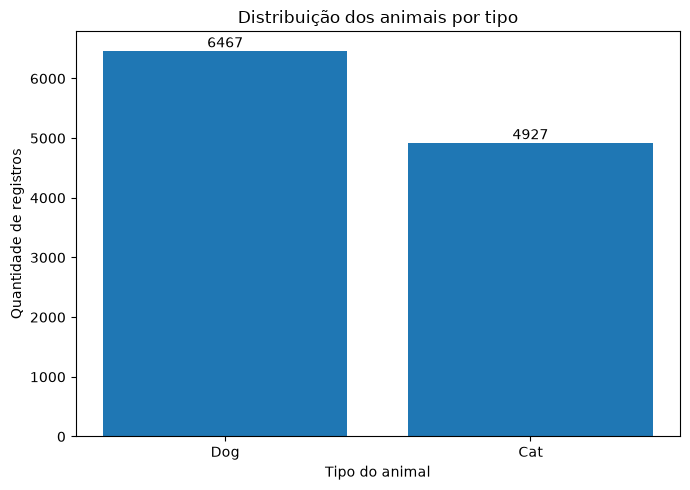

In [94]:
contagem_tipo = df_processado["Type"].value_counts()

plt.figure(figsize=(7, 5))

barras = plt.bar(
    contagem_tipo.index,
    contagem_tipo.values
)

plt.title("Distribuição dos animais por tipo")
plt.xlabel("Tipo do animal")
plt.ylabel("Quantidade de registros")

for barra in barras:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(altura)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### Interpretação

O gráfico mostra uma maior presença de cães na base, com 6.467 registros, enquanto os gatos correspondem a 4.927 registros. Apesar dessa diferença, os dois tipos possuem participação significativa no conjunto de dados.

Para o projeto IAnjos de Patas, essa característica é relevante porque o tipo de animal pode ser utilizado como um dos critérios para relacionar as preferências informadas pelo usuário às características dos animais cadastrados.

#### Distribuição dos animais por porte

O porte é uma das características que podem ser consideradas na busca por animais compatíveis com as preferências dos usuários. Por isso, analisamos a distribuição dos registros entre as categorias de porte pequeno, médio e grande.

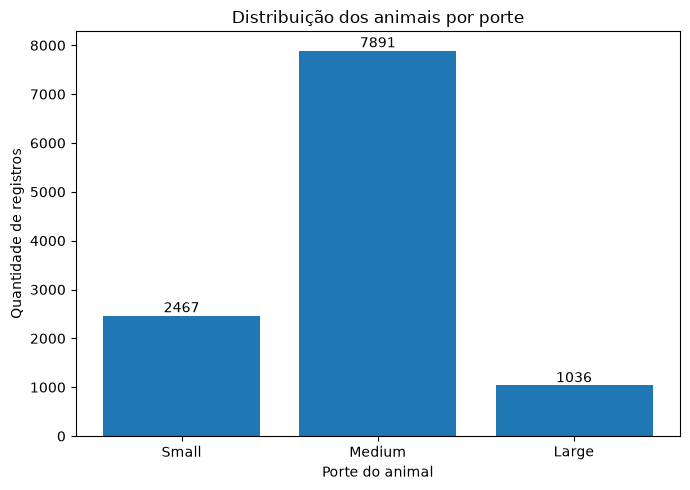

In [95]:
ordem_porte = ["Small", "Medium", "Large"]

contagem_porte = (
    df_processado["MaturitySize"]
    .value_counts()
    .reindex(ordem_porte)
)

plt.figure(figsize=(7, 5))

barras = plt.bar(
    contagem_porte.index,
    contagem_porte.values
)

plt.title("Distribuição dos animais por porte")
plt.xlabel("Porte do animal")
plt.ylabel("Quantidade de registros")

for barra in barras:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(altura)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### Interpretação

O gráfico evidencia uma concentração de animais de porte médio, que representam 7.891 registros (69,26% da base). Os animais de porte pequeno aparecem em 2.467 registros (21,65%), enquanto os de porte grande correspondem a 1.036 registros (9,09%).

Essa distribuição mostra que as categorias de porte não estão representadas de maneira equilibrada no conjunto de dados. Para o projeto IAnjos de Patas, essa característica é importante porque o porte pode ser utilizado como um dos critérios de compatibilidade entre as preferências do usuário e as características dos animais.

#### Distribuição da idade dos animais

A idade também é uma característica relevante para o projeto, pois pode fazer parte das preferências informadas pelos usuários. Para compreender como os animais estão distribuídos em relação à idade, analisamos a frequência dos registros por faixas de idade.

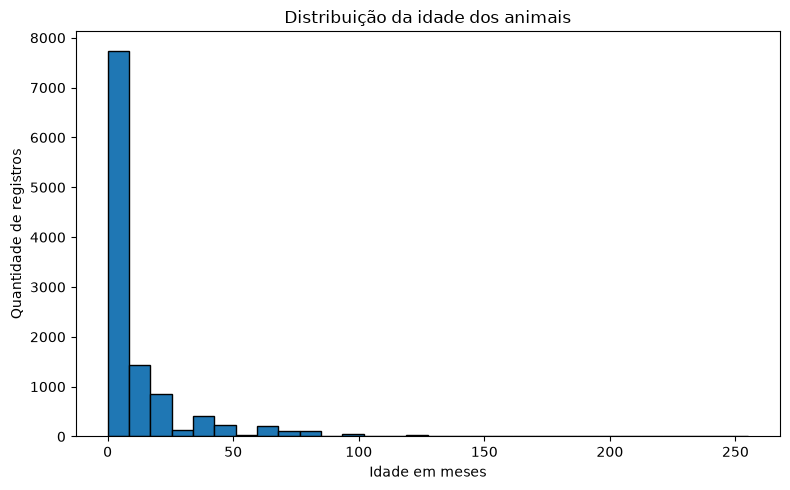

In [96]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_processado["Age"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribuição da idade dos animais")
plt.xlabel("Idade em meses")
plt.ylabel("Quantidade de registros")

plt.tight_layout()
plt.show()

#### Interpretação

A distribuição das idades apresenta uma forte concentração nos primeiros meses de vida, enquanto a quantidade de registros diminui à medida que a idade aumenta. Essa característica produz uma distribuição assimétrica, com uma extensão para idades mais elevadas.

Esse comportamento também explica a diferença observada anteriormente entre a média e a mediana da idade. Enquanto a mediana é de 4 meses, a média é de aproximadamente 11,86 meses, pois os registros de animais mais velhos aumentam o valor da média.

Como os valores extremos ampliam a escala do gráfico e dificultam a visualização das idades mais frequentes, também analisamos os animais por faixas de idade.

In [97]:
faixas = [-1, 6, 12, 36, 84, float("inf")]

rotulos = [
    "0 a 6 meses",
    "7 a 12 meses",
    "13 a 36 meses",
    "37 a 84 meses",
    "Acima de 84 meses"
]

df_processado["FaixaIdade"] = pd.cut(
    df_processado["Age"],
    bins=faixas,
    labels=rotulos
)

contagem_faixas = df_processado["FaixaIdade"].value_counts().sort_index()

contagem_faixas

FaixaIdade
0 a 6 meses          7234
7 a 12 meses         1729
13 a 36 meses        1565
37 a 84 meses         740
Acima de 84 meses     126
Name: count, dtype: int64

In [98]:
percentual_faixas = (
    df_processado["FaixaIdade"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

percentual_faixas

FaixaIdade
0 a 6 meses          63.49
7 a 12 meses         15.17
13 a 36 meses        13.74
37 a 84 meses         6.49
Acima de 84 meses     1.11
Name: proportion, dtype: float64

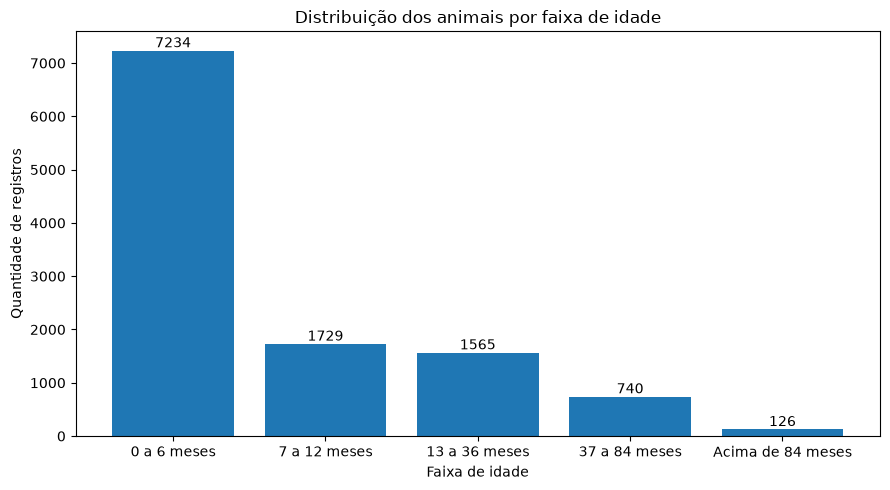

In [99]:
plt.figure(figsize=(9, 5))

barras = plt.bar(
    contagem_faixas.index,
    contagem_faixas.values
)

plt.title("Distribuição dos animais por faixa de idade")
plt.xlabel("Faixa de idade")
plt.ylabel("Quantidade de registros")

for barra in barras:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(altura)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### Interpretação por faixas de idade

A análise por faixas de idade evidencia a concentração de animais jovens no conjunto de dados. A faixa de 0 a 6 meses reúne 7.234 registros, correspondendo a 63,49% da base. Quando considerados também os animais entre 7 e 12 meses, observa-se que 78,66% dos registros possuem até 12 meses de idade.

A quantidade de registros diminui nas faixas de idade mais elevadas. Os animais entre 13 e 36 meses representam 13,74% da base, aqueles entre 37 e 84 meses correspondem a 6,49%, e apenas 1,11% possuem mais de 84 meses.

Essa concentração deve ser considerada na interpretação dos resultados, pois o conjunto de dados possui uma representação maior de animais mais jovens. Para o projeto IAnjos de Patas, a idade continua sendo uma característica relevante para a busca por compatibilidade, mas a distribuição da base precisa ser considerada ao analisar padrões relacionados a essa variável.

### 2.4 Análise da velocidade de adoção

A variável `AdoptionSpeed` representa categorias ordenadas relacionadas à velocidade de adoção dos animais. Nesta etapa, analisamos inicialmente a distribuição dessas categorias e, posteriormente, sua relação com algumas características dos animais.

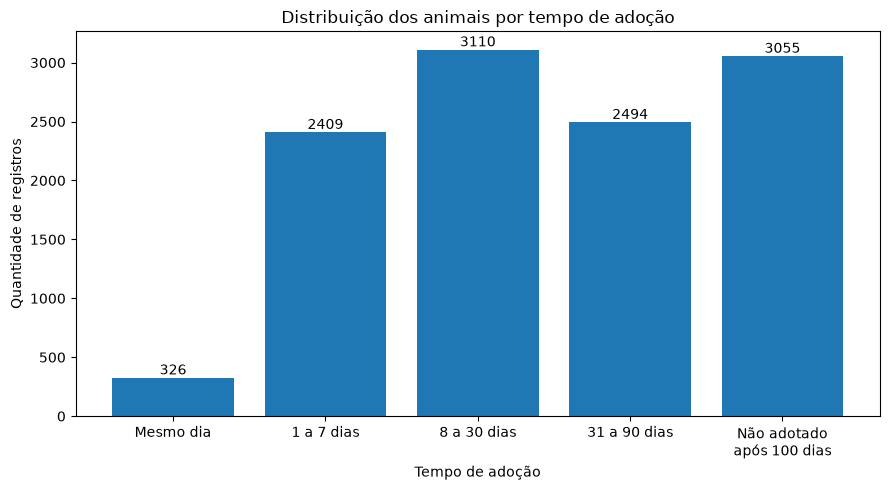

In [100]:
rotulos_adocao = {
    0: "Mesmo dia",
    1: "1 a 7 dias",
    2: "8 a 30 dias",
    3: "31 a 90 dias",
    4: "Não adotado\napós 100 dias"
}

contagem_adocao = (
    df_processado["AdoptionSpeed"]
    .value_counts()
    .sort_index()
)

rotulos = [
    rotulos_adocao[categoria]
    for categoria in contagem_adocao.index
]

plt.figure(figsize=(9, 5))

barras = plt.bar(
    rotulos,
    contagem_adocao.values
)

plt.title("Distribuição dos animais por tempo de adoção")
plt.xlabel("Tempo de adoção")
plt.ylabel("Quantidade de registros")

for barra in barras:
    altura = barra.get_height()

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(altura)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### Interpretação

A variável `AdoptionSpeed` representa o tempo necessário para a adoção do animal após a publicação do anúncio. Valores menores indicam adoções mais rápidas: a categoria 0 representa animais adotados no mesmo dia; a categoria 1, entre 1 e 7 dias; a categoria 2, entre 8 e 30 dias; e a categoria 3, entre 31 e 90 dias. A categoria 4 representa os animais que não foram adotados após 100 dias.

Na base analisada, a categoria 0 possui a menor quantidade de registros, com 326 animais. As categorias 2 e 4 apresentam as maiores frequências, com 3.110 e 3.055 registros, respectivamente.

A presença de 3.055 registros na categoria 4 mostra que uma parcela relevante dos animais da base não havia sido adotada após 100 dias. Essa variável será utilizada nas próximas análises para investigar se determinadas características dos animais apresentam relação com a velocidade de adoção.

### 2.5 Relação entre porte e velocidade de adoção

Após analisar individualmente as principais características dos animais e a variável `AdoptionSpeed`, iniciamos a análise das relações entre as variáveis.

Primeiramente, analisamos a relação entre o porte do animal (`MaturitySize`) e a velocidade de adoção (`AdoptionSpeed`). Como a quantidade de animais é diferente entre as categorias de porte, foram utilizados percentuais dentro de cada categoria, permitindo uma comparação proporcional entre animais pequenos, médios e grandes.

In [101]:
porte_adocao = pd.crosstab(
    df_processado["MaturitySize"],
    df_processado["AdoptionSpeed"],
    normalize="index"
) * 100

porte_adocao = porte_adocao.reindex(
    ["Small", "Medium", "Large"]
)

porte_adocao = porte_adocao.round(2)

porte_adocao

AdoptionSpeed,0,1,2,3,4
MaturitySize,,,,,
Small,4.58,26.43,26.96,18.36,23.67
Medium,2.22,18.92,27.85,23.36,27.65
Large,3.67,25.48,23.84,19.11,27.90


In [102]:
porte_adocao.columns = [
    "Mesmo dia",
    "1 a 7 dias",
    "8 a 30 dias",
    "31 a 90 dias",
    "Não adotado após 100 dias"
]

porte_adocao.index = [
    "Pequeno",
    "Médio",
    "Grande"
]

porte_adocao

,Mesmo dia,1 a 7 dias,8 a 30 dias,31 a 90 dias,Não adotado após 100 dias
Pequeno,4.58,26.43,26.96,18.36,23.67
Médio,2.22,18.92,27.85,23.36,27.65
Grande,3.67,25.48,23.84,19.11,27.90


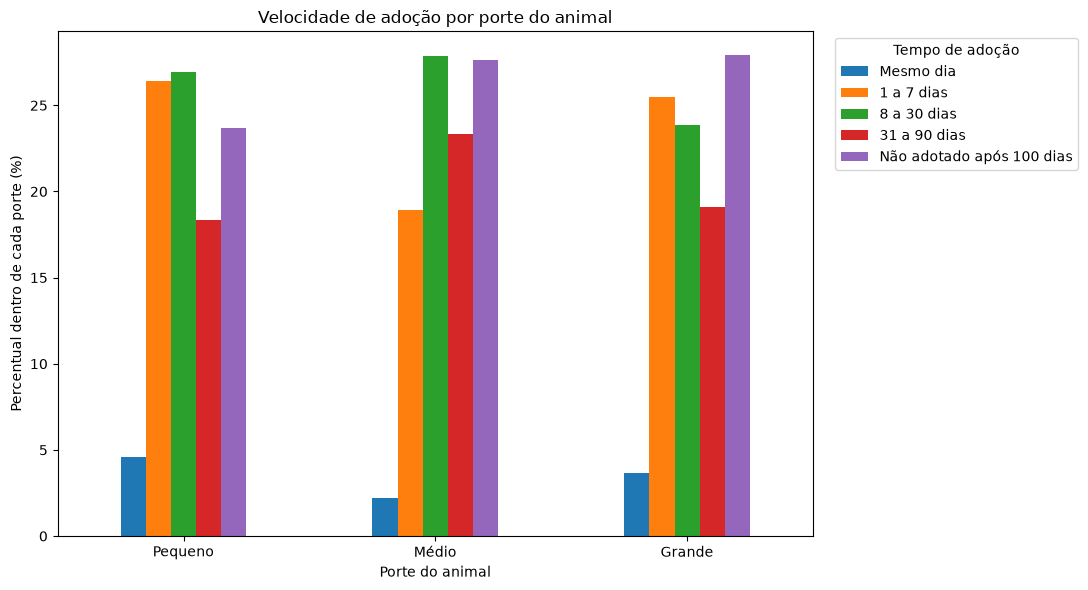

In [103]:
ax = porte_adocao.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Velocidade de adoção por porte do animal")
plt.xlabel("Porte do animal")
plt.ylabel("Percentual dentro de cada porte (%)")
plt.xticks(rotation=0)

plt.legend(
    title="Tempo de adoção",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### Interpretação

A análise proporcional indica diferenças na distribuição da velocidade de adoção entre as categorias de porte. Entre os animais pequenos, 4,58% foram adotados no mesmo dia e 26,43% entre 1 e 7 dias, totalizando 31,01% de adoções em até 7 dias. Entre os animais médios, esse percentual foi de 21,14%, enquanto entre os animais grandes foi de 29,15%.

Também foram observadas diferenças na categoria correspondente aos animais não adotados após 100 dias. Essa situação representa 23,67% dos animais pequenos, 27,65% dos médios e 27,90% dos grandes.

Os resultados sugerem uma associação entre o porte e a velocidade de adoção nesta base, com os animais pequenos apresentando menor proporção de permanência superior a 100 dias e maior proporção de adoções em até 7 dias quando comparados principalmente aos animais de porte médio.

Esses resultados representam associações observadas no conjunto de dados e não permitem concluir que o porte, isoladamente, seja responsável pela velocidade de adoção, uma vez que outras características dos animais também podem estar relacionadas ao processo.

### 2.6 Relação entre idade e velocidade de adoção

A idade é outra característica relevante para a busca por compatibilidade no projeto IAnjos de Patas. Para investigar sua possível relação com a velocidade de adoção, foram utilizadas as faixas de idade criadas anteriormente para a análise exploratória.

Assim como na análise do porte, foram utilizados percentuais dentro de cada faixa de idade, evitando que diferenças na quantidade de animais entre os grupos prejudiquem a comparação.

In [104]:
idade_adocao = pd.crosstab(
    df_processado["FaixaIdade"],
    df_processado["AdoptionSpeed"],
    normalize="index"
) * 100

idade_adocao = idade_adocao.round(2)

idade_adocao.columns = [
    "Mesmo dia",
    "1 a 7 dias",
    "8 a 30 dias",
    "31 a 90 dias",
    "Não adotado após 100 dias"
]

idade_adocao

,Mesmo dia,1 a 7 dias,8 a 30 dias,31 a 90 dias,Não adotado após 100 dias
FaixaIdade,,,,,
0 a 6 meses,2.85,24.38,30.77,22.56,19.44
7 a 12 meses,2.83,12.96,22.33,21.11,40.78
13 a 36 meses,3.07,17.57,17.89,19.55,41.92
37 a 84 meses,2.57,17.57,25.54,22.03,32.30
Acima de 84 meses,3.17,12.70,23.02,22.22,38.89


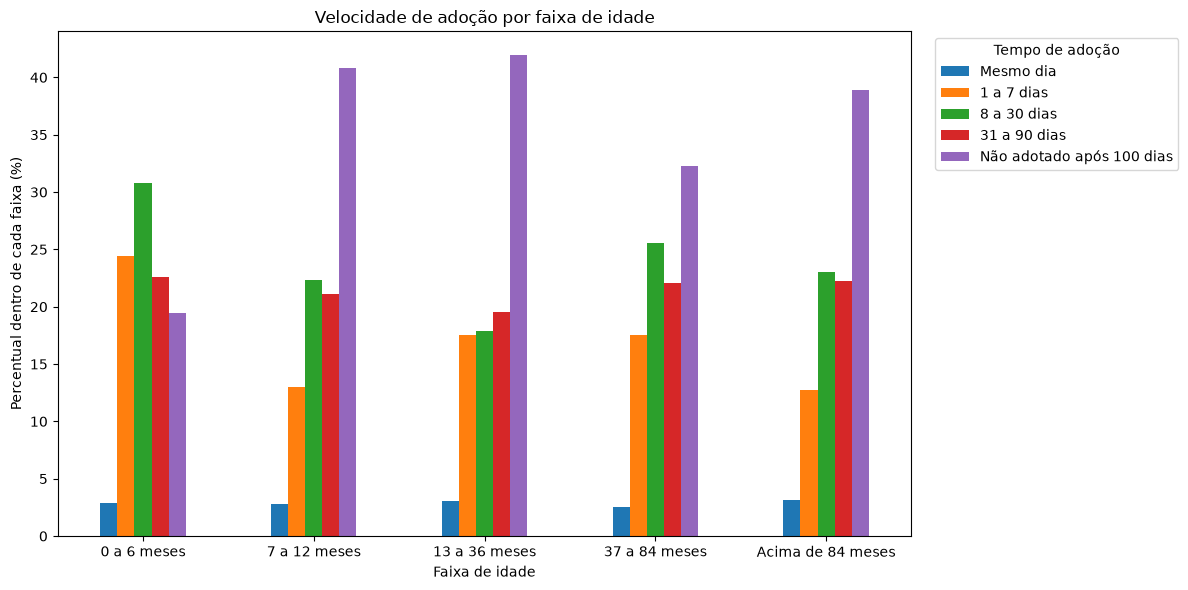

In [105]:
ax = idade_adocao.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Velocidade de adoção por faixa de idade")
plt.xlabel("Faixa de idade")
plt.ylabel("Percentual dentro de cada faixa (%)")
plt.xticks(rotation=0)

plt.legend(
    title="Tempo de adoção",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### Interpretação

A análise indica diferenças na distribuição da velocidade de adoção entre as faixas de idade. Entre os animais de 0 a 6 meses, 2,85% foram adotados no mesmo dia e 24,38% entre 1 e 7 dias, totalizando 27,23% de adoções em até 7 dias. Nessa mesma faixa, 19,44% dos registros estão na categoria de animais não adotados após 100 dias.

Nas demais faixas de idade, a proporção de animais não adotados após 100 dias é maior. Entre 7 e 12 meses, esse percentual corresponde a 40,78%, enquanto entre 13 e 36 meses chega a 41,92%. Para os animais entre 37 e 84 meses, o percentual é de 32,30%, e entre aqueles acima de 84 meses, 38,89%.

Os resultados sugerem uma associação entre idade e velocidade de adoção, principalmente pela diferença observada entre os animais de até 6 meses e as demais faixas. Entretanto, não foi observado um aumento contínuo da proporção de não adoção à medida que a idade aumenta. Portanto, os dados não permitem afirmar que animais progressivamente mais velhos apresentam necessariamente maior tempo para adoção.

Para o projeto IAnjos de Patas, esse resultado reforça a relevância da idade como uma característica a ser considerada na análise dos animais, especialmente porque ela também pode fazer parte das preferências informadas pelos usuários.

### 2.7 Relação entre quantidade de fotos e velocidade de adoção

Além das características dos animais, o conjunto de dados contém informações relacionadas aos anúncios de adoção. Uma delas é `PhotoAmt`, que representa a quantidade de fotos disponíveis no registro.

Nesta análise, investigamos a distribuição da quantidade de fotos entre as diferentes categorias de `AdoptionSpeed`, buscando identificar possíveis padrões entre a quantidade de imagens disponíveis e a velocidade de adoção.

In [106]:
fotos_adocao = (
    df_processado
    .groupby("AdoptionSpeed", observed=True)["PhotoAmt"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

fotos_adocao.index = [
    "Mesmo dia",
    "1 a 7 dias",
    "8 a 30 dias",
    "31 a 90 dias",
    "Não adotado após 100 dias"
]

fotos_adocao.columns = [
    "Quantidade de registros",
    "Média de fotos",
    "Mediana de fotos",
    "Mínimo",
    "Máximo"
]

fotos_adocao

,Quantidade de registros,Média de fotos,Mediana de fotos,Mínimo,Máximo
Mesmo dia,326,3.27,3.0,0,19
1 a 7 dias,2409,3.46,3.0,0,27
8 a 30 dias,3110,3.76,3.0,0,30
31 a 90 dias,2494,4.36,3.0,0,30
Não adotado após 100 dias,3055,3.07,2.0,0,30


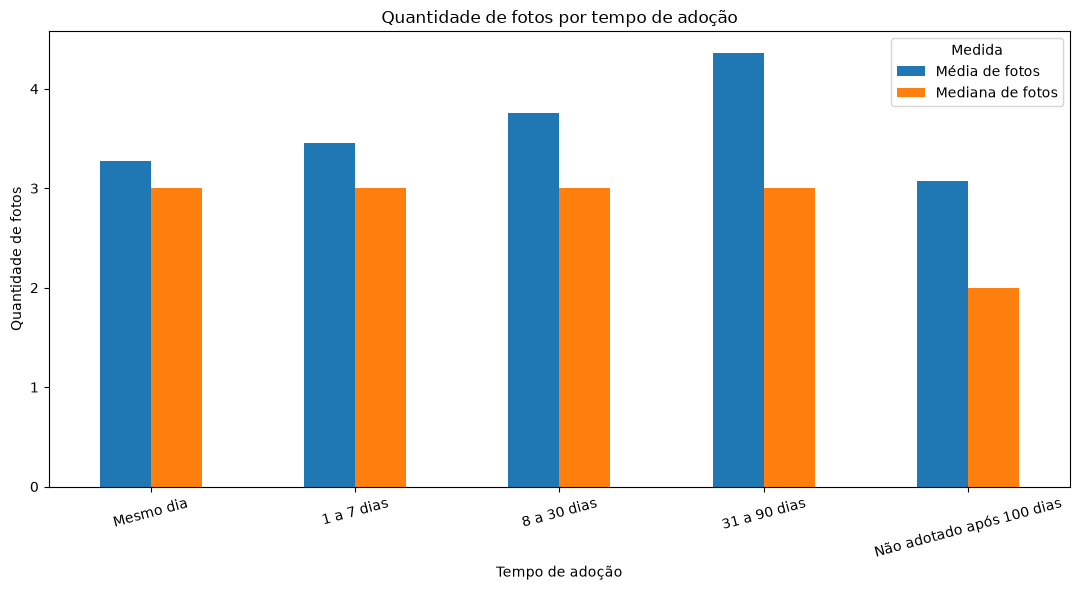

In [107]:
comparacao_fotos = fotos_adocao[
    ["Média de fotos", "Mediana de fotos"]
]

ax = comparacao_fotos.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Quantidade de fotos por tempo de adoção")
plt.xlabel("Tempo de adoção")
plt.ylabel("Quantidade de fotos")
plt.xticks(rotation=15)

plt.legend(title="Medida")

plt.tight_layout()
plt.show()

#### Interpretação

A quantidade de fotos apresenta diferenças entre as categorias de velocidade de adoção, mas não foi observado um padrão linear em que uma maior quantidade de fotos esteja associada necessariamente a uma adoção mais rápida.

Os animais adotados no mesmo dia apresentam média de 3,27 fotos, enquanto aqueles adotados entre 1 e 7 dias possuem média de 3,46. Nas categorias de 8 a 30 dias e de 31 a 90 dias, as médias aumentam para 3,76 e 4,36 fotos, respectivamente. Já entre os animais não adotados após 100 dias, a média diminui para 3,07 fotos.

A mediana é de 3 fotos nas quatro primeiras categorias de `AdoptionSpeed` e de 2 fotos entre os animais não adotados após 100 dias. Esse resultado indica que existem diferenças na quantidade de fotos entre os grupos, principalmente no grupo de animais não adotados após 100 dias, mas não permite concluir que o aumento da quantidade de fotos resulte diretamente em uma adoção mais rápida.

Outros fatores relacionados aos animais e aos próprios anúncios podem estar associados à velocidade de adoção, portanto os resultados devem ser interpretados como uma associação observada no conjunto de dados, e não como uma relação de causa e efeito.

### 2.8 Relação entre tipo do animal e velocidade de adoção

O tipo do animal é uma das características consideradas pelo projeto IAnjos de Patas na busca por compatibilidade. Para verificar se cães e gatos apresentam diferenças em relação à velocidade de adoção, analisamos a distribuição proporcional das categorias de `AdoptionSpeed` dentro de cada tipo de animal.

A utilização de percentuais permite comparar os grupos independentemente da diferença existente entre a quantidade de cães e gatos no conjunto de dados.

In [108]:
tipo_adocao = pd.crosstab(
    df_processado["Type"],
    df_processado["AdoptionSpeed"],
    normalize="index"
) * 100

tipo_adocao = tipo_adocao.round(2)

tipo_adocao.columns = [
    "Mesmo dia",
    "1 a 7 dias",
    "8 a 30 dias",
    "31 a 90 dias",
    "Não adotado após 100 dias"
]

tipo_adocao.index = [
    "Gato" if tipo == "Cat" else "Cão"
    for tipo in tipo_adocao.index
]

tipo_adocao

,Mesmo dia,1 a 7 dias,8 a 30 dias,31 a 90 dias,Não adotado após 100 dias
Gato,3.71,24.74,28.09,18.92,24.54
Cão,2.21,18.40,26.69,24.15,28.54


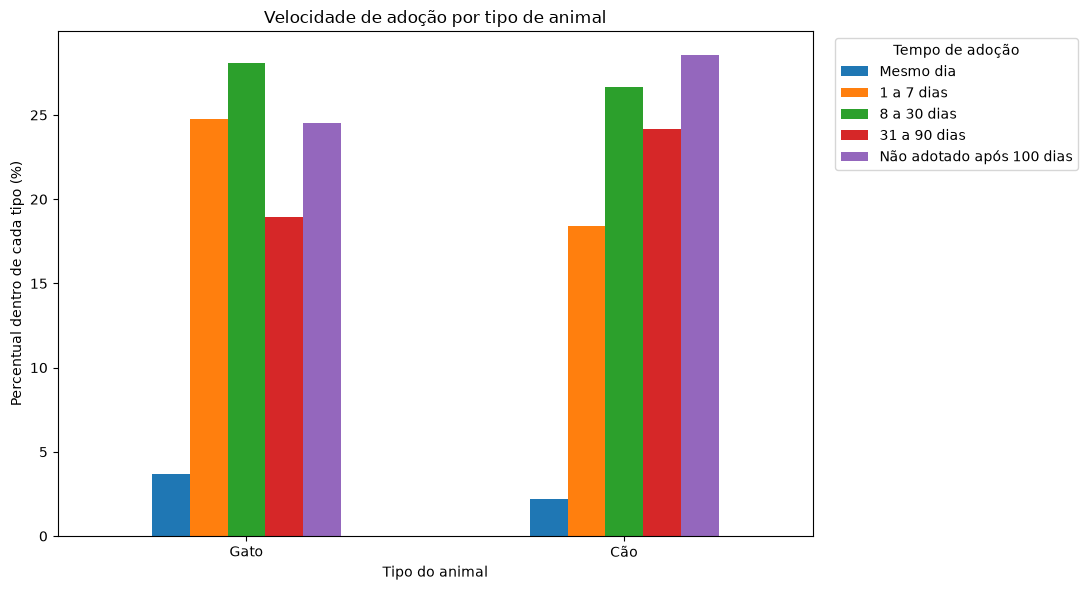

In [109]:
ax = tipo_adocao.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Velocidade de adoção por tipo de animal")
plt.xlabel("Tipo do animal")
plt.ylabel("Percentual dentro de cada tipo (%)")
plt.xticks(rotation=0)

plt.legend(
    title="Tempo de adoção",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### Interpretação

A análise proporcional mostra diferenças na distribuição da velocidade de adoção entre cães e gatos. Entre os gatos, 3,71% foram adotados no mesmo dia e 24,74% entre 1 e 7 dias, totalizando 28,45% de adoções em até 7 dias. Entre os cães, esses percentuais foram de 2,21% e 18,40%, respectivamente, totalizando 20,61%.

Na categoria correspondente aos animais não adotados após 100 dias, os gatos representam proporcionalmente 24,54% dos registros de seu grupo, enquanto entre os cães esse percentual é de 28,54%.

Os resultados indicam uma associação entre o tipo do animal e a velocidade de adoção nesta base, com os gatos apresentando maior proporção de adoções em até 7 dias e menor proporção de permanência superior a 100 dias quando comparados aos cães.

Essa diferença não permite concluir que o tipo do animal seja, isoladamente, responsável pela velocidade de adoção, pois outras características presentes nos registros também podem estar relacionadas ao processo.

### 2.9 Principais padrões e tendências identificados

A análise exploratória permitiu identificar características importantes na composição do conjunto de dados e algumas associações entre as variáveis analisadas.

A base apresenta maior quantidade de cães do que gatos e uma concentração significativa de animais de porte médio. Em relação à idade, 63,49% dos registros estão na faixa de 0 a 6 meses e 78,66% possuem até 12 meses, indicando uma forte presença de animais jovens no conjunto de dados.

A análise da velocidade de adoção mostrou diferenças relacionadas a algumas características dos animais. Os animais pequenos apresentaram maior proporção de adoções em até 7 dias quando comparados principalmente aos animais de porte médio. Em relação à idade, os animais de 0 a 6 meses apresentaram menor proporção de registros na categoria de não adotados após 100 dias do que as demais faixas analisadas.

Também foram observadas diferenças entre cães e gatos. Proporcionalmente, os gatos apresentaram maior frequência de adoções em até 7 dias e menor frequência na categoria de não adotados após 100 dias quando comparados aos cães.

A quantidade de fotos também apresentou diferenças entre as categorias de velocidade de adoção. Entretanto, não foi identificado um padrão linear que permita afirmar que uma maior quantidade de fotos esteja associada necessariamente a adoções mais rápidas.

Esses resultados representam padrões e associações presentes no conjunto de dados analisado e não estabelecem relações de causa e efeito. Outras características dos animais e dos anúncios podem estar relacionadas à velocidade de adoção.

### 2.10 Relação dos resultados com o projeto IAnjos de Patas

O projeto IAnjos de Patas tem como objetivo facilitar a localização de animais compatíveis com as preferências informadas pelos usuários. Nesse contexto, a análise exploratória mostra que características como tipo, idade e porte estão disponíveis de forma estruturada no conjunto de dados e podem ser utilizadas como critérios para a busca por compatibilidade.

A distribuição dessas características também evidencia que as categorias não estão representadas de maneira uniforme. Há maior concentração de animais jovens e de porte médio, por exemplo. Essa característica deve ser considerada na utilização dos dados, pois determinadas combinações de preferências podem encontrar uma quantidade maior ou menor de animais disponíveis.

As relações observadas com `AdoptionSpeed` mostram ainda que características como idade, porte e tipo apresentam diferentes distribuições de velocidade de adoção na base analisada. Embora o objetivo inicial do MVP não seja prever automaticamente a adoção, essas informações contribuem para compreender melhor o conjunto de dados e podem apoiar futuras análises sobre os animais cadastrados.

Dessa forma, a etapa de limpeza e análise exploratória contribui para garantir que os dados utilizados pelo projeto estejam mais consistentes e para compreender quais características podem ser utilizadas na busca por animais compatíveis com as preferências dos usuários.